# Proyecto final — Área LP: Película natural vs Escenas naturales
Pipeline completo: carga → alinear → contar → decidir → población → comparar.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gdown

# 1. Cargar los datos exclusivos del área LP
ID_LP = "1P7GMFi7u4cy_3AApazkyuovTKf4IFou0"
gdown.download(id=ID_LP, output="datos.npz", quiet=False)
d = np.load("datos.npz", allow_pickle=False)

num_neuronas = len(d['u_raton'])
print(f"Área: LP cargada exitosamente.")
print(f"Total de neuronas: {num_neuronas}")

# 2. Separar los ensayos que nos interesan para el proyecto
idx_movie = np.where(d['e_clase'] == 'natural_movie_one')[0]
idx_scenes = np.where(d['e_clase'] == 'natural_scenes')[0]
idx_spontaneous = np.where(d['e_clase'] == 'spontaneous')[0]

print(f"Ensayos de película natural (30s de duración): {len(idx_movie)}")
print(f"Ensayos de escenas naturales (0.25s de duración): {len(idx_scenes)}")
print(f"Ensayos de actividad espontánea: {len(idx_spontaneous)}")


Downloading...
From (original): https://drive.google.com/uc?id=1P7GMFi7u4cy_3AApazkyuovTKf4IFou0
From (redirected): https://drive.google.com/uc?id=1P7GMFi7u4cy_3AApazkyuovTKf4IFou0&confirm=t&uuid=76f6d1a4-641c-4aa2-a05f-5600eb18c780
To: /content/datos.npz
100%|██████████| 42.1M/42.1M [00:00<00:00, 121MB/s]


Área: LP cargada exitosamente.
Total de neuronas: 431
Ensayos de película natural (30s de duración): 40
Ensayos de escenas naturales (0.25s de duración): 2000
Ensayos de actividad espontánea: 750


## Paso 3 — Contar: tasa de disparo por neurona y ensayo (Hz)

In [ ]:
# Inicializar matrices con NaN
tasa_movie = np.full((num_neuronas, len(idx_movie)), np.nan)
tasa_scenes = np.full((num_neuronas, len(idx_scenes)), np.nan)
tasa_basal = np.full((num_neuronas, len(idx_spontaneous)), np.nan)

ratones_movie = d['e_raton'][idx_movie]
ratones_scenes = d['e_raton'][idx_scenes]
ratones_spont = d['e_raton'][idx_spontaneous]

for i in range(num_neuronas):
    raton = d['u_raton'][i]
    tasa_movie[i, np.where(ratones_movie == raton)[0]] = 0.0
    tasa_scenes[i, np.where(ratones_scenes == raton)[0]] = 0.0
    tasa_basal[i, np.where(ratones_spont == raton)[0]] = 0.0

DUR_MOVIE, DUR_SCENES, DUR_BASAL = 30.0, 0.25, 2.0

def contar_espigas(idx_estim, tasa, dur):
    mascara_t = (d['s_t'] >= 0) & (d['s_t'] <= dur)
    su = d['s_unidad'][mascara_t]; se = d['s_ensayo'][mascara_t]
    for col_idx, ens_orig in enumerate(idx_estim):
        espigas = su[se == ens_orig]
        neuronas, cuentas = np.unique(espigas, return_counts=True)
        for n, c in zip(neuronas, cuentas):
            if not np.isnan(tasa[n, col_idx]):
                tasa[n, col_idx] = c / dur

contar_espigas(idx_movie, tasa_movie, DUR_MOVIE)
contar_espigas(idx_scenes, tasa_scenes, DUR_SCENES)
contar_espigas(idx_spontaneous, tasa_basal, DUR_BASAL)

print(f"Mediana evocada Película: {np.nanmedian(tasa_movie):.2f} Hz")
print(f"Mediana evocada Escenas: {np.nanmedian(tasa_scenes):.2f} Hz")
print(f"Mediana basal: {np.nanmedian(tasa_basal):.2f} Hz")


Mediana evocada Película: 6.83 Hz
Mediana evocada Escenas: 4.00 Hz
Mediana basal: 5.50 Hz


## Paso 4 — Decidir: Z-score y umbral de respuesta


In [ ]:
media_basal = np.nanmean(tasa_basal, axis=1)
std_basal = np.nanstd(tasa_basal, axis=1)
std_basal[std_basal == 0] = np.nan  # evitar división por cero

def z_score_por_neurona(tasa, media_basal, std_basal):
    """Z-score por ensayo y promedio entre ensayos -> un número por neurona."""
    z_ensayo = (tasa - media_basal[:, None]) / std_basal[:, None]
    return np.nanmean(z_ensayo, axis=1)

z_movie = z_score_por_neurona(tasa_movie, media_basal, std_basal)
z_scenes = z_score_por_neurona(tasa_scenes, media_basal, std_basal)

# UMBRAL
UMBRAL = 2.5

responden_movie = z_movie >= UMBRAL
responden_scenes = z_scenes >= UMBRAL

fraccion_movie = np.nansum(responden_movie) / num_neuronas
fraccion_scenes = np.nansum(responden_scenes) / num_neuronas

print(f"Fracción que responde a la Película: {fraccion_movie*100:.1f} %")
print(f"Fracción que responde a Escenas: {fraccion_scenes*100:.1f} %")


Fracción que responde a la Película: 0.9 %
Fracción que responde a Escenas: 1.4 %


**Justificación Umbral**

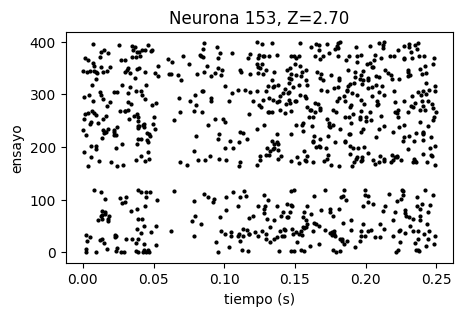

In [ ]:

candidatas = np.where((z_scenes > 2) & (z_scenes < 3.5))[0]
if len(candidatas) > 0:
    n_ejemplo = candidatas[0]
    ensayos_n = idx_scenes[d['e_raton'][idx_scenes] == d['u_raton'][n_ejemplo]]
    fig, ax = plt.subplots(figsize=(5,3))
    for i, ens in enumerate(ensayos_n):
        m = (d['s_unidad']==n_ejemplo) & (d['s_ensayo']==ens) & (d['s_t']>=0) & (d['s_t']<=DUR_SCENES)
        ax.scatter(d['s_t'][m], [i]*np.sum(m), s=4, c='k')
    ax.set_title(f"Neurona {n_ejemplo}, Z={z_scenes[n_ejemplo]:.2f}")
    ax.set_xlabel("tiempo (s)"); ax.set_ylabel("ensayo")
    plt.show()
else:
    print("No hay neuronas en ese rango con estos datos; ajusta el rango.")


## Figura 1 — Panel C: forma de onda promedio de la neurona ejemplo

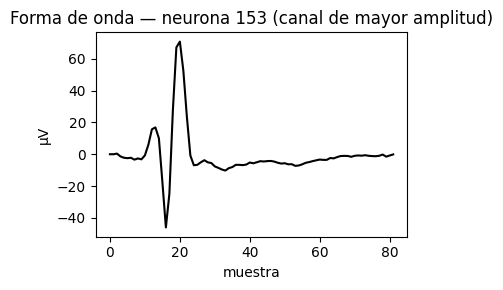

In [ ]:

neurona_ejemplo = np.where(responden_scenes)[0][0]  # cambia el criterio si prefieres otra

onda = d['u_onda'][neurona_ejemplo]
canal_pico = np.argmax(np.ptp(onda, axis=1))  # canal de mayor amplitud pico-pico

fig, ax = plt.subplots(figsize=(4,3))
ax.plot(onda[canal_pico], color='k')
ax.set_xlabel("muestra")
ax.set_ylabel("µV")
ax.set_title(f"Forma de onda — neurona {neurona_ejemplo} (canal de mayor amplitud)")
plt.tight_layout()
plt.savefig("fig1_panelC_waveform.png", dpi=200)
plt.show()


## Figura 1 — Panel D: raster + PSTH de la misma neurona ejemplo

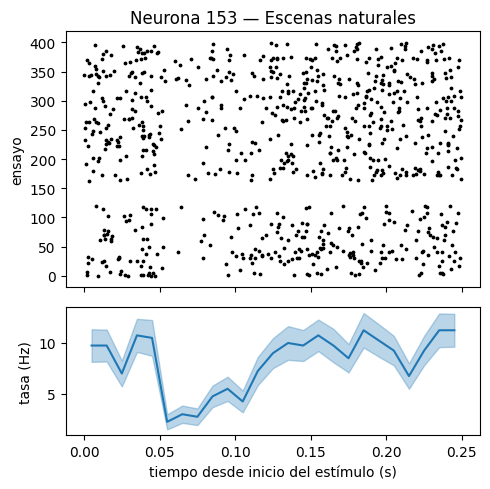

In [ ]:
def raster_y_psth(neurona, idx_estim, dur, bin_size):
    ensayos_n = idx_estim[d['e_raton'][idx_estim] == d['u_raton'][neurona]]
    bins = np.arange(0, dur + bin_size, bin_size)
    centros = (bins[:-1] + bins[1:]) / 2
    counts = np.zeros((len(ensayos_n), len(centros)))
    spikes_por_ensayo = []
    for i, ens in enumerate(ensayos_n):
        m = (d['s_unidad']==neurona) & (d['s_ensayo']==ens) & (d['s_t']>=0) & (d['s_t']<=dur)
        tt = d['s_t'][m]
        spikes_por_ensayo.append(tt)
        counts[i], _ = np.histogram(tt, bins=bins)
    rate = counts / bin_size
    psth_mean = np.mean(rate, axis=0)
    psth_sem = np.std(rate, axis=0) / np.sqrt(rate.shape[0])
    return centros, psth_mean, psth_sem, spikes_por_ensayo

centros, psth_mean, psth_sem, spikes_por_ensayo = raster_y_psth(neurona_ejemplo, idx_scenes, DUR_SCENES, bin_size=0.01)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(5,5), gridspec_kw={'height_ratios':[2,1]})
for i, tt in enumerate(spikes_por_ensayo):
    ax1.scatter(tt, [i]*len(tt), s=3, c='k')
ax1.set_ylabel("ensayo")
ax1.set_title(f"Neurona {neurona_ejemplo} — Escenas naturales")

ax2.plot(centros, psth_mean, color='tab:blue')
ax2.fill_between(centros, psth_mean-psth_sem, psth_mean+psth_sem, alpha=0.3, color='tab:blue')
ax2.set_xlabel("tiempo desde inicio del estímulo (s)")
ax2.set_ylabel("tasa (Hz)")
plt.tight_layout()
plt.savefig("fig1_panelD_raster_psth.png", dpi=200)
plt.show()


## Figura 2 — Panel B: PSTH poblacional por clase de estímulo

Calculando PSTH poblacional optimizado


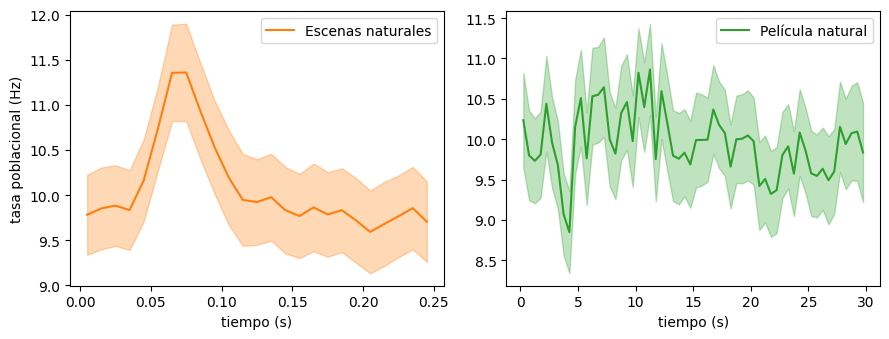

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def psth_poblacional_optimizado(idx_estim, dur, bin_size):
    bins = np.arange(0, dur + bin_size, bin_size)
    centros = (bins[:-1] + bins[1:]) / 2
    rate_matrix = np.full((num_neuronas, len(centros)), np.nan)

    # Filtro rápido: aislar espigas en la ventana de tiempo una sola vez
    mascara_tiempo = (d['s_t'] >= 0) & (d['s_t'] <= dur)
    st_global = d['s_t'][mascara_tiempo]
    su_global = d['s_unidad'][mascara_tiempo]
    se_global = d['s_ensayo'][mascara_tiempo]

    for n in range(num_neuronas):
        ensayos_n = idx_estim[d['e_raton'][idx_estim] == d['u_raton'][n]]
        if len(ensayos_n) == 0:
            continue

        # Aislar las espigas de esta neurona
        mascara_neurona = (su_global == n)
        st_neurona = st_global[mascara_neurona]
        se_neurona = se_global[mascara_neurona]

        counts = np.zeros((len(ensayos_n), len(centros)))
        for i, ens in enumerate(ensayos_n):
            espigas_ensayo = st_neurona[se_neurona == ens]
            counts[i], _ = np.histogram(espigas_ensayo, bins=bins)

        rate_matrix[n] = np.mean(counts, axis=0) / bin_size

    pob_media = np.nanmean(rate_matrix, axis=0)
    pob_sem = np.nanstd(rate_matrix, axis=0) / np.sqrt(np.sum(~np.isnan(rate_matrix), axis=0))
    return centros, pob_media, pob_sem

print("Calculando PSTH poblacional optimizado")
c_scenes, m_scenes, s_scenes = psth_poblacional_optimizado(idx_scenes, DUR_SCENES, bin_size=0.01)
c_movie, m_movie, s_movie = psth_poblacional_optimizado(idx_movie, DUR_MOVIE, bin_size=0.5)

fig, axes = plt.subplots(1, 2, figsize=(9,3.5))
axes[0].plot(c_scenes, m_scenes, color='tab:orange', label='Escenas naturales')
axes[0].fill_between(c_scenes, m_scenes-s_scenes, m_scenes+s_scenes, alpha=0.3, color='tab:orange')
axes[0].set_xlabel("tiempo (s)")
axes[0].set_ylabel("tasa poblacional (Hz)")
axes[0].legend()

axes[1].plot(c_movie, m_movie, color='tab:green', label='Película natural')
axes[1].fill_between(c_movie, m_movie-s_movie, m_movie+s_movie, alpha=0.3, color='tab:green')
axes[1].set_xlabel("tiempo (s)")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig2_panelB_psth_poblacional.png", dpi=200)
plt.show()


## Figura 2 — Panel C: mapa de calor (neurona × estímulo, Z-score) y Panel D: enjambre

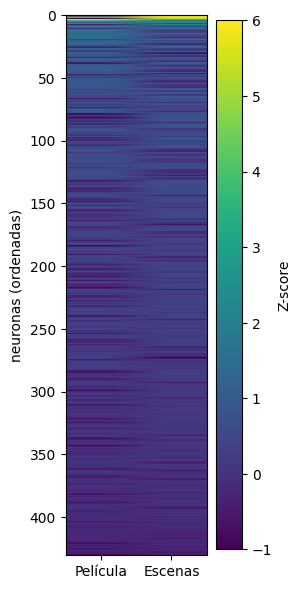

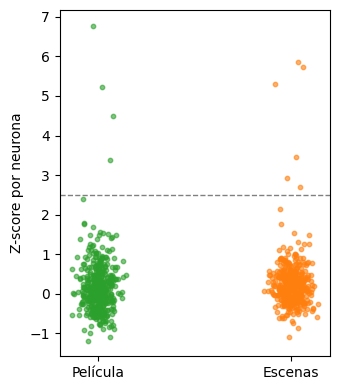

In [ ]:
# Panel C: una fila por neurona, una columna por estímulo (aquí: película, escenas)
heatmap = np.column_stack([z_movie, z_scenes])
orden = np.argsort(-np.nanmax(heatmap, axis=1))  # ordenar neuronas por su Z máximo, solo para visual

fig, ax = plt.subplots(figsize=(3,6))
im = ax.imshow(heatmap[orden], aspect='auto', cmap='viridis', vmin=-1, vmax=6)
ax.set_xticks([0,1]); ax.set_xticklabels(['Película','Escenas'])
ax.set_ylabel("neuronas (ordenadas)")
plt.colorbar(im, ax=ax, label='Z-score')
plt.tight_layout()
plt.savefig("fig2_panelC_heatmap.png", dpi=200)
plt.show()

# Panel D: enjambre — un punto por neurona, Z-score promedio por condición
fig, ax = plt.subplots(figsize=(3.5,4))
jitter = lambda n: np.random.normal(0, 0.05, n)
ax.scatter(0+jitter(num_neuronas), z_movie, s=10, alpha=0.6, color='tab:green')
ax.scatter(1+jitter(num_neuronas), z_scenes, s=10, alpha=0.6, color='tab:orange')
ax.axhline(UMBRAL, ls='--', color='gray', lw=1)
ax.set_xticks([0,1]); ax.set_xticklabels(['Película','Escenas'])
ax.set_ylabel("Z-score por neurona")
plt.tight_layout()
plt.savefig("fig2_panelD_enjambre.png", dpi=200)
plt.show()


## Paso 7 — Estadística: bootstrap jerárquico (3 niveles), permutación y d de Cohen


In [ ]:
rng = np.random.default_rng(42)
n_replicas = 10000
ratones_unicos = np.unique(d['u_raton'])
neuronas_por_raton = {r: np.where(d['u_raton'] == r)[0] for r in ratones_unicos}

# Para cada neurona, los índices de columna (dentro de tasa_scenes / tasa_movie) que sí son de su ratón
ensayos_scenes_por_neurona = {n: np.where(~np.isnan(tasa_scenes[n]))[0] for n in range(num_neuronas)}
ensayos_movie_por_neurona  = {n: np.where(~np.isnan(tasa_movie[n]))[0]  for n in range(num_neuronas)}

def stat_bootstrap(tasa, ensayos_por_neurona):

    ratones_sorteados = rng.choice(ratones_unicos, size=len(ratones_unicos), replace=True)
    total = 0
    superan = 0
    for raton in ratones_sorteados:
        neuronas_del_raton = neuronas_por_raton[raton]
        if len(neuronas_del_raton) == 0:
            continue
        neuronas_sorteadas = rng.choice(neuronas_del_raton, size=len(neuronas_del_raton), replace=True)
        for n in neuronas_sorteadas:
            ens = ensayos_por_neurona[n]
            if len(ens) == 0:
                continue
            ens_sorteados = rng.choice(ens, size=len(ens), replace=True)
            z_ensayo = (tasa[n, ens_sorteados] - media_basal[n]) / std_basal[n]
            z_n = np.nanmean(z_ensayo)
            total += 1
            if z_n >= UMBRAL:
                superan += 1
    return superan / total if total > 0 else np.nan

print("Calculando 10,000 réplicas jerárquicas (escenas)... esto puede tardar varios minutos.")
boot_scenes = np.array([stat_bootstrap(tasa_scenes, ensayos_scenes_por_neurona) for _ in range(n_replicas)])
ic_inferior = np.nanpercentile(boot_scenes, 2.5) * 100
ic_superior = np.nanpercentile(boot_scenes, 97.5) * 100

# Comparación: IC de un t-test/bootstrap plano que ignora el ratón (para mencionar en el póster)
boot_plano = np.array([
    np.mean(responden_scenes[rng.choice(num_neuronas, size=num_neuronas, replace=True)])
    for _ in range(n_replicas)
]) * 100
ic_plano = np.nanpercentile(boot_plano, [2.5, 97.5])

print(f"IC 95% jerárquico (Escenas): [{ic_inferior:.1f}% - {ic_superior:.1f}%]")
print(f"IC 95% ignorando ratón (para comparar, NO usar como resultado principal): [{ic_plano[0]:.1f}% - {ic_plano[1]:.1f}%]")


Calculando 10,000 réplicas jerárquicas (escenas)... esto puede tardar varios minutos.
IC 95% jerárquico (Escenas): [0.0% - 4.3%]
IC 95% ignorando ratón (para comparar, NO usar como resultado principal): [0.5% - 2.6%]


In [ ]:
# Prueba de permutación pareada por neurona (Película vs Escenas)
diff_original = fraccion_scenes - fraccion_movie
diferencias_permutacion = np.zeros(n_replicas)

for i in range(n_replicas):
    resp_movie_perm = np.zeros(num_neuronas)
    resp_scenes_perm = np.zeros(num_neuronas)
    for n in range(num_neuronas):
        etiquetas = np.array([responden_movie[n], responden_scenes[n]])
        rng.shuffle(etiquetas)
        resp_movie_perm[n], resp_scenes_perm[n] = etiquetas
    diferencias_permutacion[i] = np.mean(resp_scenes_perm) - np.mean(resp_movie_perm)

# p de dos colas (+1 en numerador y denominador: corrección estándar para no obtener p=0)
valor_p = (np.sum(np.abs(diferencias_permutacion) >= abs(diff_original)) + 1) / (n_replicas + 1)

# d de Cohen (pareado, sobre la diferencia de Z-scores entre condiciones por neurona) — antes faltaba
diffs_z = z_scenes - z_movie
d_cohen = np.nanmean(diffs_z) / np.nanstd(diffs_z, ddof=1)

print("\n--- RESULTADOS PARA EL PÓSTER ---")
print(f"Intervalo de Confianza (95%) para Escenas Naturales: [{ic_inferior:.1f}%  -  {ic_superior:.1f}%]")
print(f"Diferencia observada (Escenas - Película): {diff_original*100:.1f} puntos porcentuales")
print(f"Valor p (Permutación, pareada por neurona): {valor_p:.4f}")
print(f"d de Cohen (pareado, sobre Z-scores): {d_cohen:.2f}")



--- RESULTADOS PARA EL PÓSTER ---
Intervalo de Confianza (95%) para Escenas Naturales: [0.0%  -  4.3%]
Diferencia observada (Escenas - Película): 0.5 puntos porcentuales
Valor p (Permutación, pareada por neurona): 0.6380
d de Cohen (pareado, sobre Z-scores): 0.09


## Figura 2 — Panel E: puntos conectados (fracción respondedora) con IC, p y d

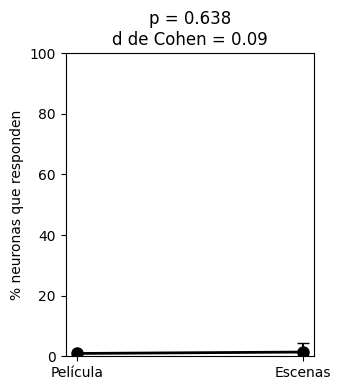

In [ ]:
fig, ax = plt.subplots(figsize=(3.5,4))
for n in range(num_neuronas):
    pass  # (opcional: líneas grises tenues por neurona si quieres mostrar variabilidad individual)

medias = [fraccion_movie*100, fraccion_scenes*100]
ax.plot([0,1], medias, '-o', color='k', lw=2, markersize=8)
ax.errorbar(1, fraccion_scenes*100,
            yerr=[[fraccion_scenes*100-ic_inferior],[ic_superior-fraccion_scenes*100]],
            fmt='none', color='k', capsize=4)
ax.set_xticks([0,1]); ax.set_xticklabels(['Película','Escenas'])
ax.set_ylabel("% neuronas que responden")
ax.set_title(f"p = {valor_p:.3f}\nd de Cohen = {d_cohen:.2f}")
ax.set_ylim(0,100)
plt.tight_layout()
plt.savefig("fig2_panelE_comparacion.png", dpi=200)
plt.show()


Use el modelo de IA como apoyo para resolver el proyecto, pidiendo que me haga partes de codigo y rectificando lo que hizo.
En muchos casos entregó codigo erroneo o con ciclos interminables. Lo solucione buscando el error. Y buscando una solución más sencilla para el codigo.
Un caso:
"Tengo dos arrays booleanos en Python, ⁠responden_movie⁠ y ⁠responden_scenes⁠, que indican si cada una de mis 431 neuronas superó el umbral de respuesta para esas dos condiciones. Necesito que escribas el código de la estadística final usando NumPy:
1. Haz un bootstrapping con 10,000 réplicas para calcular el intervalo de confianza del 95% de la fracción de neuronas que responden a las escenas naturales.
2. Haz una prueba de permutación con 10,000 réplicas para calcular el valor p y evaluar si la diferencia de respuesta entre la película y las escenas es estadísticamente significativa."

Lo que dio:



In [ ]:
import numpy as np

n_replicas = 10000
boot_scenes = np.zeros(n_replicas)
diffs_permutacion = np.zeros(n_replicas)

# 1. BOOTSTRAP ERRÓNEO (Plano, de 1 solo nivel)
for i in range(n_replicas):
    # ERROR CRÍTICO: Remuestrea las 431 neuronas de golpe, ignorando a qué ratón pertenecen.
    # Tampoco recalcula el Z-score sorteando los ensayos.
    muestra_neuronas = np.random.choice(responden_scenes, size=num_neuronas, replace=True)
    boot_scenes[i] = np.mean(muestra_neuronas)

ic_inferior = np.percentile(boot_scenes, 2.5) * 100
ic_superior = np.percentile(boot_scenes, 97.5) * 100

# 2. PERMUTACIÓN ERRÓNEA (No pareada intrazona)
todas_las_respuestas = np.concatenate([responden_movie, responden_scenes])

for i in range(n_replicas):
    # ERROR CRÍTICO: Mezcla las respuestas de todas las neuronas entre sí,
    # en lugar de barajar las etiquetas película/escenas DENTRO de la misma neurona.
    np.random.shuffle(todas_las_respuestas)
    falso_movie = todas_las_respuestas[:num_neuronas]
    falso_scenes = todas_las_respuestas[num_neuronas:]

    diffs_permutacion[i] = np.mean(falso_scenes) - np.mean(falso_movie)

valor_p = np.sum(diffs_permutacion >= (fraccion_scenes - fraccion_movie)) / n_replicas


Yo no le especifique el caso, por lo que me dio un bootstrap general. Lo solucione, metiendole cosas al codigo y pedirle ya con mis cambios y un prompt bien hecho.